### Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path 
import json 
import pickle 
from datetime import datetime 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import VarianceThreshold 

import warnings 
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

### Load Engineered Features

In [2]:
data_path = 'C:/Users/parth/Market-Anomaly-Detection-System/data/processed/features_engineered.csv'

if not Path(data_path).exists():
    print(f"Error: {data_path} not found.")
else:
    data = pd.read_csv(data_path)

    print(f"Data loaded successfully!")
    print(f"\n📊 Dataset Info:")
    print(f"   • Shape: {data.shape}")
    print(f"   • Rows: {data.shape[0]:,}")
    print(f"   • Columns: {data.shape[1]}")

Data loaded successfully!

📊 Dataset Info:
   • Shape: (283726, 71)
   • Rows: 283,726
   • Columns: 71


### Data Overview

In [3]:
# Display first few rows 
display(data.head())

# Check for issues 
print(f"\n🔍 Data Quality Checks:")
print(f"   • Missing values: {data.isnull().sum().sum()}")
print(f"   • Duplicate rows: {data.duplicated().sum()}")

# Class distribution 
class_dist = data['Class'].value_counts()
fraud_rate = data['Class'].mean() * 100

print(f"\n⚖️  Class Distribution:")
print(f"   • Legitimate (0): {class_dist[0]:,} ({100-fraud_rate:.3f}%)")
print(f"   • Fraud (1): {class_dist[1]:,} ({fraud_rate:.3f}%)")
print(f"   • Imbalance Ratio: 1:{int(class_dist[0]/class_dist[1])}")


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,transaction_order,time_seconds,hour,day,day_of_week,is_weekend,is_night,is_business_hours,is_early_morning,user_id,time_since_last,count_1hr,count_6hr,count_24hr,sum_amount_1hr,sum_amount_6hr,sum_amount_24hr,txn_frequency,user_avg_amount,user_std_amount,user_median_amount,user_min_amount,user_max_amount,user_total_transactions,amount_vs_user_avg,amount_deviation_std,amount_vs_user_max,is_user_max_amount,amount_zscore,amount_log,amount_sqrt,amount_squared,amount_modified_zscore,amount_bin,V1_V2_interaction,V3_V4_interaction,V5_V6_interaction,amount_hour_interaction,amount_weekend_interaction,velocity_amount_interaction
0,86431.0,0.018701,0.851804,0.191363,-0.781137,0.677382,-0.595121,0.964369,-0.083319,-0.396098,-0.266365,0.613002,1.115703,0.726189,0.141988,-1.161796,0.162164,-0.818305,-0.238762,0.320220,0.037734,-0.219311,-0.457058,0.016666,-0.322927,-0.450161,0.138048,0.246635,0.085844,6.49,0,144277,432831,0.230833,5,5,1,1,0,0,0,0.0,1.0,1.0,1.0,6.49,6.49,6.49,1.0,4.955275,4.473976,3.59,0.0,44.99,400,1.309715,0.343034,0.144254,0,-0.327408,2.013569,2.547548,42.1201,-0.517384,0,0.015930,-0.149481,-0.403125,1.498108,6.49,6.49
1,86689.0,0.016932,0.817619,0.179232,-0.788480,0.672991,-0.518816,0.909360,-0.028159,-0.321133,-0.258262,0.570919,0.869180,0.226961,0.245464,-1.059624,0.128992,-0.736664,-0.265044,0.255656,-0.006730,-0.221562,-0.475316,0.021382,-0.395716,-0.482063,0.145472,0.247596,0.083864,3.87,0,144620,433860,0.516667,5,5,1,1,0,0,0,1029.0,2.0,2.0,2.0,10.36,10.36,10.36,2.0,4.955275,4.473976,3.59,0.0,44.99,400,0.780986,-0.242575,0.086019,0,-0.337872,1.583094,1.967232,14.9769,-0.604782,0,0.013844,-0.141321,-0.349159,1.999500,3.87,7.74
2,86992.0,0.018491,0.797472,0.175902,-0.773904,0.610339,-0.613492,0.912225,-0.040196,-0.281262,-0.243918,0.483759,0.712694,-0.031716,0.292792,-1.078659,0.197670,-0.774981,-0.145864,0.325388,-0.011283,-0.228148,-0.519111,0.025269,-0.343652,-0.475890,0.140594,0.241754,0.084201,6.28,0,144937,434811,0.780833,5,5,1,1,0,0,0,951.0,3.0,3.0,3.0,16.64,16.64,16.64,3.0,4.955275,4.473976,3.59,0.0,44.99,400,1.267336,0.296096,0.139587,0,-0.328247,1.985131,2.505993,39.4384,-0.524389,0,0.014746,-0.136131,-0.374438,4.903633,6.28,18.84
3,87279.0,-0.000624,0.771348,0.172190,-0.779243,0.664105,-0.536734,0.881046,-0.011132,-0.278281,-0.249555,0.523727,0.723989,-0.047505,0.301368,-1.028504,0.141713,-0.720645,-0.230036,0.257323,-0.015513,-0.222094,-0.499265,0.032315,-0.403518,-0.489832,0.146354,0.244507,0.083810,5.36,0,145357,436071,1.130833,5,5,1,1,0,1,0,1260.0,4.0,4.0,4.0,22.00,22.00,22.00,4.0,4.955275,4.473976,3.59,0.0,44.99,400,1.081675,0.090462,0.119138,0,-0.331921,1.850028,2.315167,28.7296,-0.555078,0,-0.000481,-0.134178,-0.356448,6.061267,5.36,21.44
4,87371.0,0.025722,0.833333,0.185405,-0.779896,0.640839,-0.604526,0.933298,-0.059678,-0.333162,-0.252942,0.542560,0.895885,0.312188,0.223814,-1.116784,0.181269,-0.794625,-0.189009,0.323463,0.005319,-0.225726,-0.490432,0.015771,-0.333982,-0.465233,0.139496,0.244842,0.084694,4.47,0,145474,436422,1.228333,5,5,1,1,0,1,0,351.0,5.0,5.0,5.0,26.47,26.47,26.47,5.0,4.955275,4.473976,3.59,0.0,44.99,400,0.902069,-0.108466,0.099355,0,-0.335475,1.699279,2.114237,19.9809,-0.584767,0,0.021435,-0.144597,-0.387404,5.490650,4.47,22.35



🔍 Data Quality Checks:
   • Missing values: 0
   • Duplicate rows: 0

⚖️  Class Distribution:
   • Legitimate (0): 283,253 (99.833%)
   • Fraud (1): 473 (0.167%)
   • Imbalance Ratio: 1:598


### Define Features & Target

In [4]:
# Columns to exclude from features
exclude_columns = [
    'id',                      # Transaction ID (not a feature)
    'Class',                   # Target variable
    'transaction_order',       # Helper column
    'time_seconds'            # Helper column
]

# Define feature columns (everything except excluded)
feature_columns = [col for col in data.columns if col not in exclude_columns]

print(f"\n📊 Feature Selection:")
print(f"   • Total columns: {len(data.columns)}")
print(f"   • Excluded columns: {len(exclude_columns)} {exclude_columns}")
print(f"   • Feature columns: {len(feature_columns)}")
print(f"   • Target column: Class")


📊 Feature Selection:
   • Total columns: 71
   • Excluded columns: 4 ['id', 'Class', 'transaction_order', 'time_seconds']
   • Feature columns: 68
   • Target column: Class


In [5]:
# Separate features and target
X = data[feature_columns].copy()
y = data['Class'].copy()

print(f"\n✓ Feature matrix (X): {X.shape}")
print(f"✓ Target vector (y): {y.shape}")


✓ Feature matrix (X): (283726, 68)
✓ Target vector (y): (283726,)


In [6]:
# Show feature list
print(f"\n📋 Feature Categories:")
print(f"   • PCA Features (V1-V28): 28")
print(f"   • Amount Features: ~5")
print(f"   • Temporal Features: ~7")
print(f"   • Velocity Features: ~8")
print(f"   • Behavioral Features: ~10")
print(f"   • Statistical Features: ~6")
print(f"   • Interaction Features: ~6")


📋 Feature Categories:
   • PCA Features (V1-V28): 28
   • Amount Features: ~5
   • Temporal Features: ~7
   • Velocity Features: ~8
   • Behavioral Features: ~10
   • Statistical Features: ~6
   • Interaction Features: ~6


### Handle Missing Values & Infinities

In [7]:
# Check for missing values 
missing_counts = X.isnull().sum()
if missing_counts.sum() > 0:
    print("⚠️  Found {missing_counts.sum()} missing values")
    print("\nColumns with missing values:")
    display(missing_counts[missing_counts > 0])

    # Fill missing values with median 
    for col in X.columns:
        if X[col].isnull().any():
            X[col].fillna(X[col].median(), inplace = True)
    print("\n Missing values filled with median.")
else:
    print("No missing values found")

No missing values found


In [8]:
# Check for infinities 
inf_counts = np.isinf(X).sum() 
if inf_counts.sum() > 0:
    print(f"\n⚠️  Found {inf_counts.sum()} infinite values")

    # Replace infinities with large values 
    X = X.replace([np.inf, -np.inf], np.nan)
    X.fillna(X.median(), inplace = True)
    print("Infinities replaced")
else:
    print("No infinities values found")


print("Data cleaned", X.shape)

No infinities values found
Data cleaned (283726, 68)


### Train-Validation-Test Split (Temporal)

In [9]:
# Temporal split (chronological order)
# This prevents data leakage - future data not used to predict past
train_size = int(0.70 * len(X))
val_size = int(0.15 * len(X))
test_size = len(X) - train_size - val_size

In [10]:
# Split
X_train = X.iloc[:train_size].copy()
X_val = X.iloc[train_size:train_size+val_size].copy()
X_test = X.iloc[train_size+val_size:].copy()

y_train = y.iloc[:train_size].copy()
y_val = y.iloc[train_size:train_size+val_size].copy()
y_test = y.iloc[train_size+val_size:].copy()

In [11]:
print(f"📊 Split Results:")
print(f"   • Train: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   • Val:   {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"   • Test:  {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")

📊 Split Results:
   • Train: 198,608 samples (70.0%)
   • Val:   42,558 samples (15.0%)
   • Test:  42,560 samples (15.0%)


In [12]:
# Check fraud distribution in each set
train_fraud = y_train.mean() * 100
val_fraud = y_val.mean() * 100
test_fraud = y_test.mean() * 100

In [13]:
print(f"\n⚖️  Fraud Distribution:")
print(f"   • Train: {y_train.sum():,} frauds ({train_fraud:.3f}%)")
print(f"   • Val:   {y_val.sum():,} frauds ({val_fraud:.3f}%)")
print(f"   • Test:  {y_test.sum():,} frauds ({test_fraud:.3f}%)")


⚖️  Fraud Distribution:
   • Train: 350 frauds (0.176%)
   • Val:   57 frauds (0.134%)
   • Test:  66 frauds (0.155%)


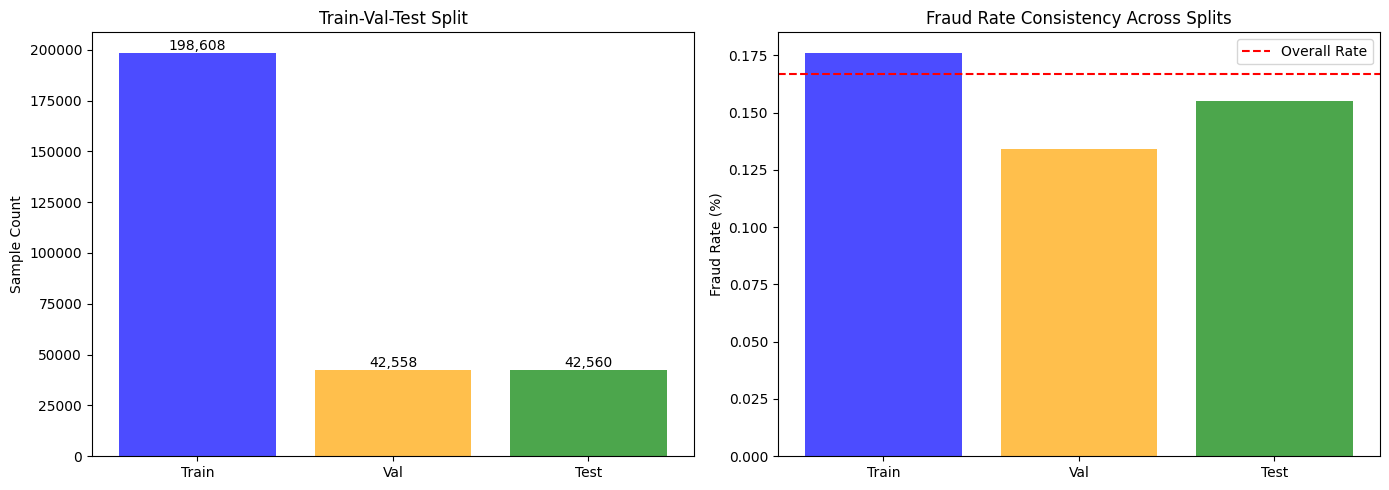

In [14]:
# Visualize split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by split
split_dist = pd.DataFrame({
    'Train': [len(X_train), len(X_val), len(X_test)],
    'Samples': ['Train', 'Val', 'Test']
})
axes[0].bar(split_dist['Samples'], split_dist['Train'], alpha=0.7, color=['blue', 'orange', 'green'])
axes[0].set_ylabel('Sample Count')
axes[0].set_title('Train-Val-Test Split')
for i, v in enumerate(split_dist['Train']):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# Fraud rate by split
fraud_rates = [train_fraud, val_fraud, test_fraud]
axes[1].bar(['Train', 'Val', 'Test'], fraud_rates, alpha=0.7, color=['blue', 'orange', 'green'])
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate Consistency Across Splits')
axes[1].axhline(y=fraud_rate, color='r', linestyle='--', label='Overall Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

### Feature Scaling (StandardScaler)

In [15]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data 
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [16]:
print("✓ StandardScaler applied")
print(f"   • Fit on train set: {X_train.shape}")
print(f"   • Transformed val set: {X_val.shape}")
print(f"   • Transformed test set: {X_test.shape}")

✓ StandardScaler applied
   • Fit on train set: (198608, 68)
   • Transformed val set: (42558, 68)
   • Transformed test set: (42560, 68)


In [17]:
# Convert back to DataFrame for easier handling
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [18]:
# Show scaling effect
print(f"\n📊 Scaling Effect (Amount feature example):")
print(f"   Before scaling:")
print(f"      Mean: {X_train['Amount'].mean():.2f}")
print(f"      Std:  {X_train['Amount'].std():.2f}")
print(f"   After scaling:")
print(f"      Mean: {X_train_scaled_df['Amount'].mean():.6f}")
print(f"      Std:  {X_train_scaled_df['Amount'].std():.6f}")


📊 Scaling Effect (Amount feature example):
   Before scaling:
      Mean: 88.11
      Std:  259.24
   After scaling:
      Mean: 0.000000
      Std:  1.000003


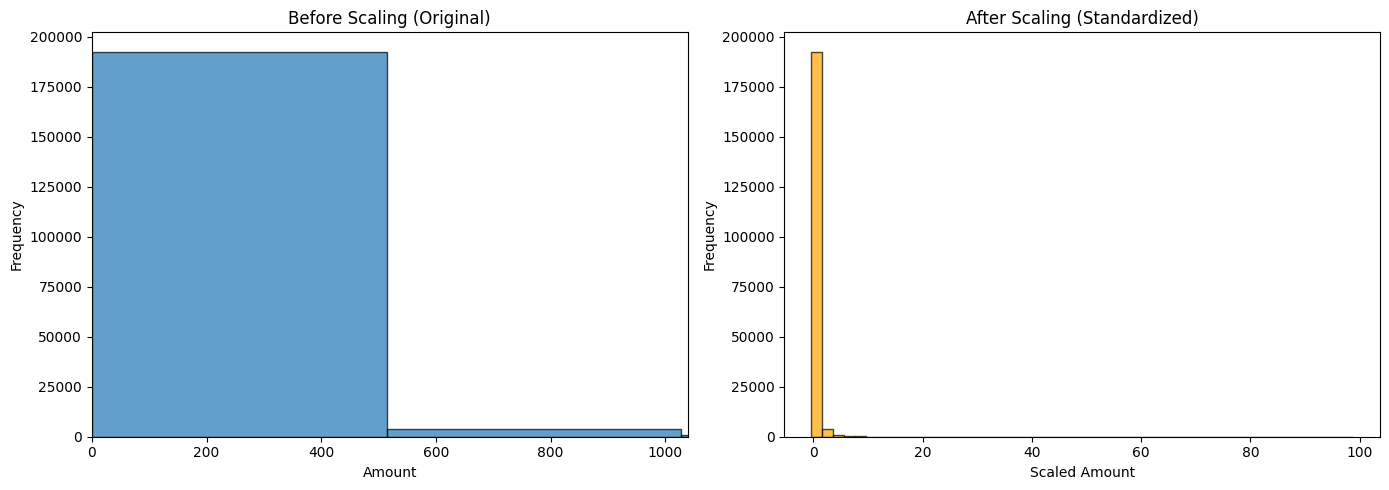

In [19]:
# Visualize scaling effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].hist(X_train['Amount'], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Before Scaling (Original)')
axes[0].set_xlim([0, X_train['Amount'].quantile(0.99)])

# After scaling
axes[1].hist(X_train_scaled_df['Amount'], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_xlabel('Scaled Amount')
axes[1].set_ylabel('Frequency')
axes[1].set_title('After Scaling (Standardized)')

plt.tight_layout()
plt.show()

### Feature Selection - Remove Low Variance Features

In [20]:
# Calculate variance for each feature
feature_variances = X_train_scaled_df.var().sort_values()

In [21]:
print(f"📊 Feature Variance Analysis:")
print(f"   • Min variance: {feature_variances.min():.6f}")
print(f"   • Max variance: {feature_variances.max():.6f}")
print(f"   • Mean variance: {feature_variances.mean():.6f}")


📊 Feature Variance Analysis:
   • Min variance: 1.000005
   • Max variance: 1.000005
   • Mean variance: 1.000005


In [22]:
# Show lowest variance features
print(f"\n📋 10 Lowest Variance Features:")
display(feature_variances.head(10))


📋 10 Lowest Variance Features:


is_user_max_amount    1.000005
V1                    1.000005
V5                    1.000005
V2                    1.000005
V6                    1.000005
V10                   1.000005
V9                    1.000005
V4                    1.000005
V14                   1.000005
V13                   1.000005
dtype: float64

In [23]:
# Apply variance threshold
variance_threshold = 0.01  # Remove features with variance < 0.01
selector = VarianceThreshold(threshold=variance_threshold)

In [24]:
X_train_selected = selector.fit_transform(X_train_scaled_df)
X_val_selected = selector.transform(X_val_scaled_df)
X_test_selected = selector.transform(X_test_scaled_df)

In [25]:
# Get selected feature names
selected_features = X_train_scaled_df.columns[selector.get_support()].tolist()
removed_features = X_train_scaled_df.columns[~selector.get_support()].tolist()

print(f"\n✓ Feature Selection Complete:")
print(f"   • Original features: {X_train_scaled_df.shape[1]}")
print(f"   • Removed features: {len(removed_features)}")
print(f"   • Selected features: {len(selected_features)}")

if removed_features:
    print(f"\n📋 Removed Features (low variance):")
    print(f"   {removed_features}")


✓ Feature Selection Complete:
   • Original features: 68
   • Removed features: 0
   • Selected features: 68


In [26]:
# Convert back to DataFrame
X_train_final = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train.index)
X_val_final = pd.DataFrame(X_val_selected, columns=selected_features, index=X_val.index)
X_test_final = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)

print(f"\n✓ Final feature matrices created:")
print(f"   • Train: {X_train_final.shape}")
print(f"   • Val:   {X_val_final.shape}")
print(f"   • Test:  {X_test_final.shape}")


✓ Final feature matrices created:
   • Train: (198608, 68)
   • Val:   (42558, 68)
   • Test:  (42560, 68)


### Save Processed Data

In [27]:
# Create directory
output_dir = Path('C:/Users/parth/Market-Anomaly-Detection-System/data/processed')

X_train_final.to_csv('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/X_train.csv', index=False)
X_val_final.to_csv('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/X_val.csv', index=False)
X_test_final.to_csv('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/X_test.csv', index=False)
y_train.to_csv('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/y_train.csv', index=False, header=True)
y_val.to_csv('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/y_val.csv', index=False, header=True)
y_test.to_csv('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/y_test.csv', index=False, header=True)

print("✓ CSV files saved")

✓ CSV files saved


In [28]:
# Save as NumPy arrays (faster for model training)
print("\nSaving NumPy arrays...")
np.save('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/X_train.npy', X_train_final.values)
np.save('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/X_val.npy', X_val_final.values)
np.save('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/X_test.npy', X_test_final.values)

np.save('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/y_train.npy', y_train.values)
np.save('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/y_val.npy', y_val.values)
np.save('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/y_test.npy', y_test.values)
print("✓ NumPy arrays saved")


Saving NumPy arrays...
✓ NumPy arrays saved


In [29]:
# Save scaler and selector (needed for production)
print("\nSaving transformers...")
with open('C:/Users/parth/Market-Anomaly-Detection-System/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved: models/scaler.pkl")

with open('C:/Users/parth/Market-Anomaly-Detection-System/models/variance_selector.pkl', 'wb') as f:
    pickle.dump(selector, f)
print("✓ Variance selector saved: models/variance_selector.pkl")


Saving transformers...
✓ Scaler saved: models/scaler.pkl
✓ Variance selector saved: models/variance_selector.pkl
